Importing Required Libraries

In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
from IPython.display import display

Constructing the Quantum Oracle

In [2]:
def simon_oracle(s):
    qc = QuantumCircuit(4, 2)
    
    # Initialize the function for the specific s
    if s == '11':
        # This implements f(x) for s=11
        qc.cx(0, 2)
        qc.cx(1, 2)
        qc.cx(0, 3)
        qc.cx(1, 3)
    
    return qc

Building Simon's Algorithm Circuit

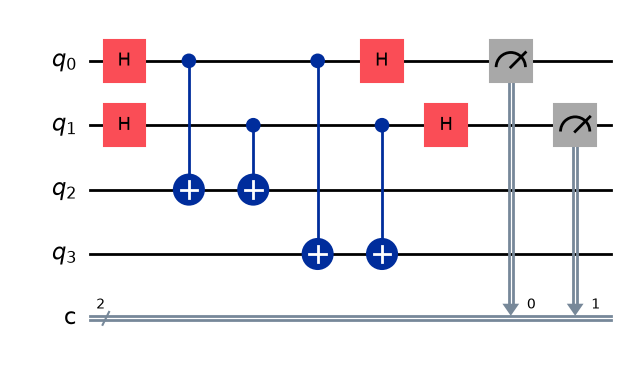

In [3]:
# Number of qubits
n = 2

# Create the main circuit
simon_circuit = QuantumCircuit(n*2, n)

# Apply Hadamard gates to the first register
simon_circuit.h(range(n))

# Add the oracle
oracle = simon_oracle('11')
simon_circuit.compose(oracle, inplace=True)

# Apply Hadamard gates to the first register again
simon_circuit.h(range(n))

# Measure the first register
simon_circuit.measure(range(n), range(n))

# Draw the circuit
display(simon_circuit.draw('mpl'))

Simulating the Circuit

In [4]:
# Use AerSimulator
simulator = AerSimulator()

# Transpile the circuit for the simulator
compiled_circuit = transpile(simon_circuit, simulator)

# Run the simulation
job = simulator.run(compiled_circuit, shots=1024)
result = job.result()
counts = result.get_counts()

# Print the results
print("Measurement results:", counts)

Measurement results: {'00': 516, '11': 508}


Analyzing the Results

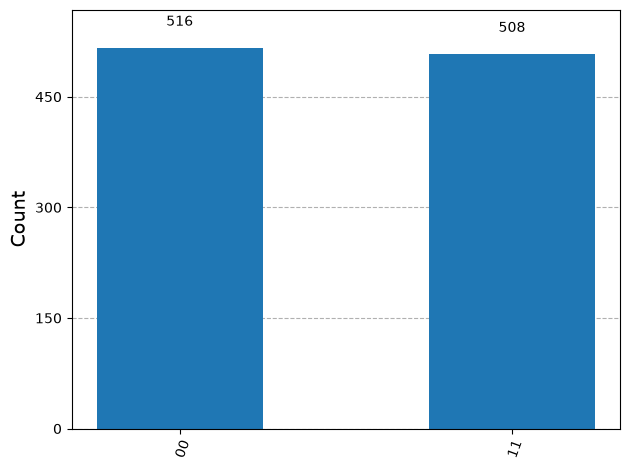

In [5]:
# Plot the histogram
display(plot_histogram(counts))